2. Contexto de Negócio

## Contexto de Negócio

Uma instituição bancária deseja compreender os principais fatores associados ao churn de clientes e identificar padrões de comportamento que possam auxiliar estratégias de retenção e relacionamento.

O projeto tem como objetivo explorar indicadores financeiros, comportamento de clientes, segmentações e métricas de negócio utilizando técnicas de Analytics Engineering e visualização executiva de dados.

3. Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import duckdb

4. Instalação DuckDB

In [2]:
!pip install duckdb

5. Carregamento dos Dados

In [4]:
df = pd.read_csv('/content/Bank Customer Churn Prediction.csv')

6. Primeira Visualização

In [5]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


7. Estrutura do Dataset

In [6]:
df.shape

(10000, 12)

8. Informações Gerais

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


9. Qualidade dos Dados

In [9]:
df.isnull().sum()

,0
customer_id,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0


In [10]:
df.duplicated().sum()

np.int64(0)

10. Feature Engineering

In [11]:
df['faixa_etaria'] = pd.cut(

    df['age'],

    bins=[18, 30, 40, 50, 60, 100],

    labels=[
        '18-30',
        '31-40',
        '41-50',
        '51-60',
        '60+'
    ]
)

11. Faixa Salarial

In [12]:
df['faixa_salario'] = pd.qcut(

    df['estimated_salary'],

    q=4,

    labels=[
        'Baixo',
        'Médio',
        'Alto',
        'Premium'
    ]
)

12. Visualizar Novas Features

In [13]:
df[
    [
        'age',
        'faixa_etaria',
        'estimated_salary',
        'faixa_salario'
    ]
].head()

,age,faixa_etaria,estimated_salary,faixa_salario
0,42,41-50,101348.88,Alto
1,41,41-50,112542.58,Alto
2,42,41-50,113931.57,Alto
3,39,31-40,93826.63,Médio
4,43,41-50,79084.10,Médio


13. KPI Layer

In [14]:
kpis = {

    'Taxa de Churn (%)':

        round(df['churn'].mean() * 100, 2),

    'Saldo Médio':

        round(df['balance'].mean(), 2),

    'Salário Médio':

        round(df['estimated_salary'].mean(), 2),

    'Clientes Ativos':

        int(df['active_member'].sum()),

    'Score Médio':

        round(df['credit_score'].mean(), 2)
}

kpis

{'Taxa de Churn (%)': np.float64(20.37),
 'Saldo Médio': np.float64(76485.89),
 'Salário Médio': np.float64(100090.24),
 'Clientes Ativos': 5151,
 'Score Médio': np.float64(650.53)}

14. SQL Analytics Layer

In [15]:
query_churn = duckdb.sql("""

SELECT

    country,

    faixa_etaria,

    ROUND(AVG(churn) * 100, 2) AS taxa_churn,

    ROUND(AVG(balance), 2) AS saldo_medio,

    COUNT(*) AS total_clientes

FROM df

GROUP BY country, faixa_etaria

ORDER BY taxa_churn DESC

""").df()

In [16]:
query_churn.head()

,country,faixa_etaria,taxa_churn,saldo_medio,total_clientes
0,Germany,51-60,69.55,121549.13,243
1,France,51-60,52.59,63908.05,367
2,Germany,41-50,48.82,119805.00,678
3,Spain,51-60,45.99,67825.85,187
4,Germany,60+,38.94,119652.79,113


15. Executive Visualization

In [17]:
df_pais = (

    df.groupby('country')['churn']

    .mean()

    .reset_index()
)

df_pais['churn'] = df_pais['churn'] * 100

In [18]:
fig = go.Figure()

fig.add_trace(

    go.Bar(

        x=df_pais['country'],

        y=df_pais['churn'],

        marker_color=[
            '#1F4E79',
            '#B0B0B0',
            '#B0B0B0'
        ],

        text=df_pais['churn'].round(2),

        textposition='outside'
    )
)

fig.update_layout(

    title='Taxa de Churn por País',

    plot_bgcolor='white',

    showlegend=False,

    width=900,

    height=500
)

fig.update_yaxes(

    title='Taxa de Churn (%)',

    showgrid=True,

    gridcolor='lightgray'
)

fig.add_annotation(

    x='Germany',

    y=df_pais['churn'].max(),

    text='Maior taxa de churn',

    showarrow=True,

    arrowhead=2,

    bgcolor='white'
)

fig.show()

16. Dashboard KPI Executivo

In [19]:
fig = go.Figure()

fig.add_trace(go.Indicator(
    mode="number",
    value=kpis['Taxa de Churn (%)'],
    title={"text": "Taxa de Churn (%)"},
    domain={'x': [0, 0.25], 'y': [0, 1]}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=kpis['Saldo Médio'],
    title={"text": "Saldo Médio"},
    domain={'x': [0.25, 0.5], 'y': [0, 1]}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=kpis['Clientes Ativos'],
    title={"text": "Clientes Ativos"},
    domain={'x': [0.5, 0.75], 'y': [0, 1]}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=kpis['Score Médio'],
    title={"text": "Score Médio"},
    domain={'x': [0.75, 1], 'y': [0, 1]}
))

fig.update_layout(

    title='Executive KPI Dashboard',

    height=300,

    plot_bgcolor='white'
)

fig.show()

17. Segmentação Avançada

In [27]:
df_segmentacao = (

    df.groupby(
        'faixa_etaria',
        observed=False
    )['churn']

    .mean()

    .reset_index()
)

df_segmentacao['churn'] = (
    df_segmentacao['churn'] * 100
)

In [22]:
fig = go.Figure()

fig.add_trace(

    go.Bar(

        x=df_segmentacao['faixa_etaria'],

        y=df_segmentacao['churn'],

        marker_color=[
            '#B0B0B0',
            '#B0B0B0',
            '#1F4E79',
            '#C0392B',
            '#C0392B'
        ],

        text=df_segmentacao['churn'].round(2),

        textposition='outside'
    )
)

fig.update_layout(

    title='Taxa de Churn por Faixa Etária',

    plot_bgcolor='white',

    showlegend=False
)

fig.update_yaxes(

    title='Taxa de Churn (%)',

    gridcolor='lightgray'
)

fig.show()

18. Heatmap Executivo

In [23]:
corr = df[
    [
        'credit_score',
        'age',
        'balance',
        'estimated_salary',
        'tenure',
        'products_number',
        'churn'
    ]
].corr()

Heatmap

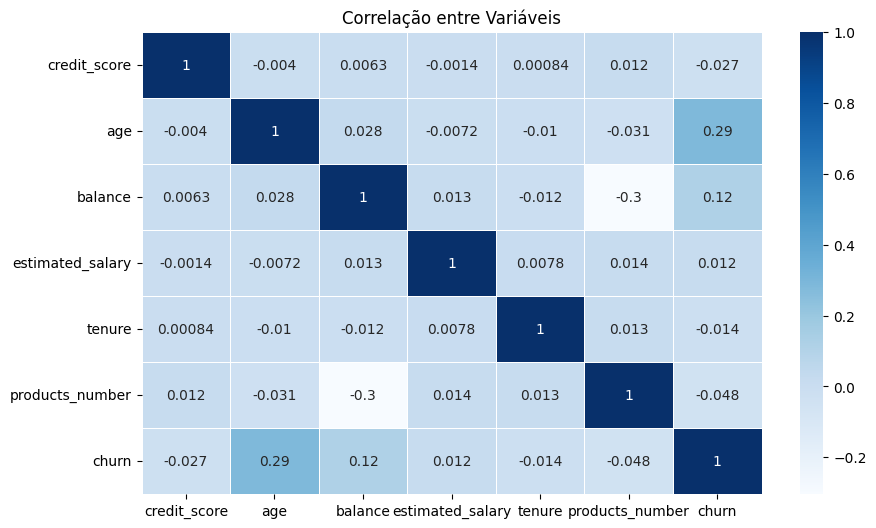

In [24]:
plt.figure(figsize=(10,6))

sns.heatmap(

    corr,

    annot=True,

    cmap='Blues',

    linewidths=0.5
)

plt.title('Correlação entre Variáveis')

plt.show()

19. Retenção de Clientes

In [25]:
df_retencao = (

    df.groupby('active_member')['churn']

    .mean()

    .reset_index()
)

df_retencao['churn'] = (
    df_retencao['churn'] * 100
)

In [26]:
fig = go.Figure()

fig.add_trace(

    go.Bar(

        x=['Inativo', 'Ativo'],

        y=df_retencao['churn'],

        marker_color=[
            '#C0392B',
            '#1F4E79'
        ],

        text=df_retencao['churn'].round(2),

        textposition='outside'
    )
)

fig.update_layout(

    title='Impacto da Atividade no Churn',

    plot_bgcolor='white',

    showlegend=False
)

fig.update_yaxes(

    title='Taxa de Churn (%)',

    gridcolor='lightgray'
)

fig.show()

20. Insights Estratégicos

## Strategic Insights

- Clientes acima de 50 anos apresentaram maior taxa de churn.
- Clientes inativos possuem risco significativamente maior de cancelamento.
- Alemanha apresentou a maior taxa de churn entre os países analisados.
- Clientes com menor engajamento apresentaram maior tendência de evasão.
- O comportamento de churn demonstrou relação com fatores financeiros e demográficos.

21. Recomendações de Negócio

## Recomendações

- Criar campanhas de retenção voltadas para clientes acima de 50 anos.
- Desenvolver estratégias de ativação para clientes inativos.
- Monitorar segmentos com maior taxa de churn.
- Aplicar campanhas personalizadas por país e perfil financeiro.